<a href="https://colab.research.google.com/github/manusmriti31/Learning_PyTorch/blob/main/Video%20notebooks/08_pytorch_paper_replicating_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 08. PyTorch Paper Replicating

The goal of machine learning research paper replicating is: turn a ML research paper into usable code.

In this notebook, we're going to be replicating the Vision Transformer (ViT) architecture/paper with PyTorch: https://arxiv.org/abs/2010.11929

See ground truth notebook here: https://www.learnpytorch.io/08_pytorch_paper_replicating/

## 0. Get Setup

Let's import code we've previously written + required libraries

In [1]:
import torch
import torchvision

print(f"torch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")

torch version: 2.6.0+cu124
torchvision version: 0.21.0+cu124


In [2]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !mv pytorch-deep-learning/helper_functions.py . # get the helper_functions.py script
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves

[INFO] Couldn't find torchinfo... installing it.
[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.
Cloning into 'pytorch-deep-learning'...
remote: Enumerating objects: 4393, done.
remote: Counting objects: 100% (1534/1534), done.
remote: Compressing objects: 100% (133/133), done.
remote: Total 4393 (delta 1457), reused 1401 (delta 1401), pack-reused 2859 (from 2)
Receiving objects: 100% (4393/4393), 650.71 MiB | 25.29 MiB/s, done.
Resolving deltas: 100% (2659/2659), done.
Updating files: 100% (248/248), done.


In [3]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 1. Get Data
The whole goal of what we're trying to do is to replicate the ViT architecture for our FoodVision Mini problem.

To do that, we need some data.

Namely, the pizza, steak and sushi images we've been using so far.

In [4]:
# Download pizza, steak, sushi images from GitHub
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                           destination="pizza_steak_sushi")
image_path

[INFO] Did not find data/pizza_steak_sushi directory, creating one...
[INFO] Downloading pizza_steak_sushi.zip from https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip...
[INFO] Unzipping pizza_steak_sushi.zip data...


PosixPath('data/pizza_steak_sushi')

In [5]:
# Setup directory paths to train and test images
train_dir = image_path / "train"
test_dir = image_path / "test"

In [6]:
train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [7]:
## 2. Create Datasets and Dataloaders

In [8]:
from torchvision import transforms
from going_modular.going_modular import data_setup

# Create image size
IMG_SIZE = 224 # Comes from table 3 of ViT

# Create transform pipeline
manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor()
])

print(f"Manually Created transforms: {manual_transforms}")

Manually Created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [9]:
# Create a batch size of 32
BATCH_SIZE = 32

# Create Dataloader
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir = train_dir,
                                                                               test_dir = test_dir,
                                                                               transform = manual_transforms,
                                                                               batch_size = BATCH_SIZE)

len(train_dataloader), len(test_dataloader), class_names

(8, 3, ['pizza', 'steak', 'sushi'])

### 2.3 Visualize a single image

In [10]:
# Get a batch of images
image_batch, label_batch = next(iter(train_dataloader))

# Get a single image and label from the batch
image, label = image_batch[0], label_batch[0]

# View the single iamge and label shapes
image.shape, label

(torch.Size([3, 224, 224]), tensor(1))

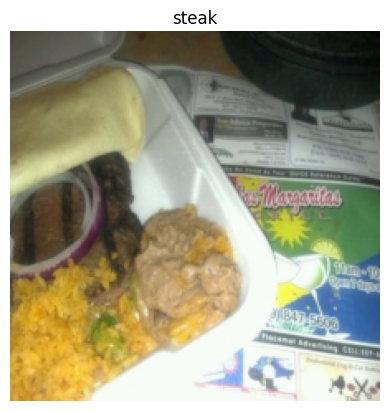

In [11]:
# Plot the image with matplot
import matplotlib.pyplot as plt

plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis(False);

## 3. Replicating ViT: Overview

Looking at a whole machine learning research paper can be imtimidating.

So in order to make it more understandable, we can break it down into smaller pieces:

- **Inputs** - What goes into the model? (in our case, image tensors)
- **Outputs** - What comes out of the model/layer/block? (in our case, we want the model to output image classification labels)
- **Layers** - Takes an input, manipulates it with a function (for example could be self-attention).
- **Blocks** - A collection of layers.
- **Model** (or architecture) - A collection of blocks.


### 3.1 ViT overview: Pieces of the puzzle

- Figure 1: Visual overview of the architecture
- Four equations: math equations which define the functions of each layer/block
- Table 1/3: different hyperparameters for the architecture/training.
- Text descriptions (especially section 3.1)


### Figure 1

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/08-vit-paper-figure-1-architecture-overview.png" width=600 alt="figure 1 from vision transformer paper"/>

* Embedding = learnable representation (start with random numbers and improve over time)



### Four equations

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/08-vit-paper-four-equations.png" width=600 alt="four equations from vision transformer paper"/>

#### Section 3.1 describes the various equations:

**Equation 1:**
An overview of the model is depicted in Figure 1. The standard Transformer receives as input a 1D sequence of token embeddings. To handle $2 \mathrm{D}$ images, we reshape the image $\mathbf{x} \in \mathbb{R}^{H \times W \times C}$ into a sequence of flattened $2 \mathrm{D}$ patches $\mathbf{x}_{p} \in \mathbb{R}^{N \times\left(P^{2} \cdot C\right)}$, where $(H, W)$ is the resolution of the original image, $C$ is the number of channels, $(P, P)$ is the resolution of each image patch, and $N=H W / P^{2}$ is the resulting number of patches, which also serves as the effective input sequence length for the Transformer. The Transformer uses constant latent vector size $D$ through all of its layers, so we flatten the patches and map to $D$ dimensions with a trainable linear projection (Eq. 1). We refer to the output of this projection as the patch embeddings.

**Equation 1:**
Position embeddings are added to the patch embeddings to retain positional information. We use standard learnable $1 \mathrm{D}$ position embeddings, since we have not observed significant performance gains from using more advanced 2D-aware position embeddings (Appendix D.4). The resulting sequence of embedding vectors serves as input to the encoder.

In pseudocode:

```python
# Equation 1
x_input = [class_token, image_patch_1, image_patch_2, ... image_patch_N] + [class_token_pos, image_patch_1_pos, image_patch_2_pos, ... image_patch_N_pos]
```



---

**Equations 2&3:**
The Transformer encoder (Vaswani et al., 2017) consists of alternating layers of multiheaded selfattention (MSA, see Appendix A) and MLP blocks (Eq. 2, 3). Layernorm (LN) is applied before every block, and residual connections after every block (Wang et al., 2019; Baevski \& Auli, 2019).

In pseudocode:

```python
# Equation 2
x_output_MSA_block = MSA_layer(LN_layer(x_input)) + x_input

# Equation 3
x_output_MLP_block = MLP_layer(LN_layer(x_output_MSA_block)) + x_output_MSA_block
```
---


**Equation 4:**
Similar to BERT's [ class ] token, we prepend a learnable embedding to the sequence of embedded patches $\left(\mathbf{z}_{0}^{0}=\mathbf{x}_{\text {class }}\right)$, whose state at the output of the Transformer encoder $\left(\mathbf{z}_{L}^{0}\right)$ serves as the image representation y (Eq. 4). Both during pre-training and fine-tuning, a classification head is attached to $\mathbf{z}_{L}^{0}$. The classification head is implemented by a MLP with one hidden layer at pre-training time and by a single linear layer at fine-tuning time.

* MLP = multilayer perceptron = a neural network with X number of layers
* MLP = one hidden layer at training time
* MLP = single linear layer at fine-tuning time

In pseudocode:

```python
# Equation 4
y = Linear_layer(LN_layer(x_output_MLP_block))
```

### Table 1

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/08-vit-paper-table-1.png" width=600 alt="table 1 from vision transformer paper"/>

* ViT-Base, ViT-Large and ViT-Huge are all different sizes of the same model architecture
* ViT-B/16 = ViT-Base with image patch size 16x16
* Layers - the number of transformer encoder layers
* Hidden size $D$ - the embedding size throughout the architecture
* MLP size - the number of hidden units/neurons in the MLP
* Heads - the number of multi-head self-attention


## 4. Equation 1: Split data into patches and creating the class, position and patch embedding

Layers = input -> function -> output

What's the input shape?

What's the output shape?

* Input shape: (224, 224, 3) -> single image -> (height, width, color channels)
* Output shape: ???

### 4.1 Calculate input and output shapes by hand

> **Equation 1:**
An overview of the model is depicted in Figure 1. The standard Transformer receives as input a 1D sequence of token embeddings. To handle $2 \mathrm{D}$ images, we reshape the image $\mathbf{x} \in \mathbb{R}^{H \times W \times C}$ into a sequence of flattened $2 \mathrm{D}$ patches $\mathbf{x}_{p} \in \mathbb{R}^{N \times\left(P^{2} \cdot C\right)}$, where $(H, W)$ is the resolution of the original image, $C$ is the number of channels, $(P, P)$ is the resolution of each image patch, and $N=H W / P^{2}$ is the resulting number of patches, which also serves as the effective input sequence length for the Transformer. The Transformer uses constant latent vector size $D$ through all of its layers, so we flatten the patches and map to $D$ dimensions with a trainable linear projection (Eq. 1). We refer to the output of this projection as the patch embeddings.

> **Equation 1:**
Position embeddings are added to the patch embeddings to retain positional information. We use standard learnable $1 \mathrm{D}$ position embeddings, since we have not observed significant performance gains from using more advanced 2D-aware position embeddings (Appendix D.4). The resulting sequence of embedding vectors serves as input to the encoder.

* Input shape: $H\times{W}\times{C}$ (height x width x color channels)
* Output shape: ${N \times\left(P^{2} \cdot C\right)}$
* H = height
* W = width
* C = color channels
* P = patch size
* N = number of patches = (height * width) / p^2
* D = constant latent vector size = embedding dimension (see Table 1)


In [12]:
# Create example values
height = 224 # H
width = 224 # W
color_channels = 3 # C
patch_size = 16 # P

# Calculate the number of patches (N = H*W / p^2)
number_of_patches = int((height * width) / patch_size ** 2) # N

number_of_patches


196

In [13]:
# Input Shape = (H x W x C)
embedding_layer_input_shape = (height, width, color_channels)

# Output Shape = (N x (P^2 * C))
embedding_layer_output_shape = (number_of_patches, patch_size**2 * color_channels)

print(f"Input Shape: {embedding_layer_input_shape}")
print(f"Output Shape: {embedding_layer_output_shape}")

Input Shape: (224, 224, 3)
Output Shape: (196, 768)


### 4.2 Turning a single image into patches

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

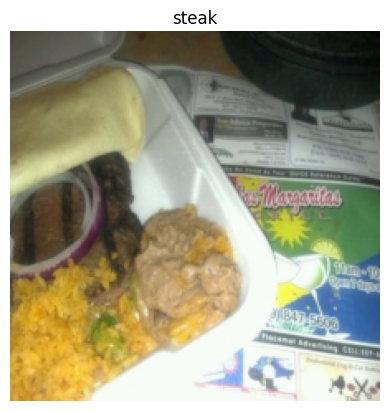

In [14]:
#  View a single image
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis(False)

In [15]:
image.shape

torch.Size([3, 224, 224])

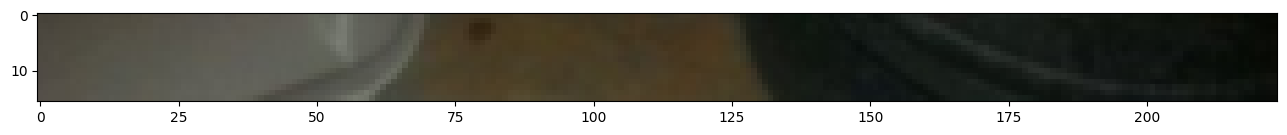

In [16]:
# Get the top row of the image
image_permuted = image.permute(1,2,0)

# Index to plot the top row
patch_size = 16
plt.figure(figsize = (patch_size, patch_size))
plt.imshow(image_permuted[:patch_size, :, :])
# plt.title(class_names[label])
# plt.axis(False);

Number of patches per row: 14.0
Patch size: 16 pixels x 16 pixels


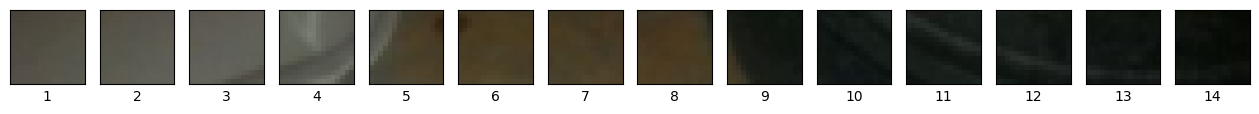

In [17]:
# Setup the code to plot the top row as patches
image_size = 224
patch_size = 16
number_of_patches = image_size / patch_size
assert image_size % patch_size == 0, "Image size should be divisible by the patch size"

print(f"Number of patches per row: {number_of_patches}\nPatch size: {patch_size} pixels x {patch_size} pixels")

fig, axs = plt.subplots(nrows = 1,
                        ncols = int(number_of_patches),
                        sharex = True,
                        sharey = True,
                        figsize = (patch_size, patch_size))

for i, patch in enumerate(range(0, image_size, patch_size)):
  axs[i].imshow(image_permuted[:patch_size, patch:patch+patch_size, :])
  axs[i].set_xlabel(i+1)
  axs[i].set_xticks([])
  axs[i].set_yticks([])

Number of patches per row: 14.0  
Number of patches per column: 14.0  
Total patches: 196.0  
Patch size: 16 pixels x 16 pixels


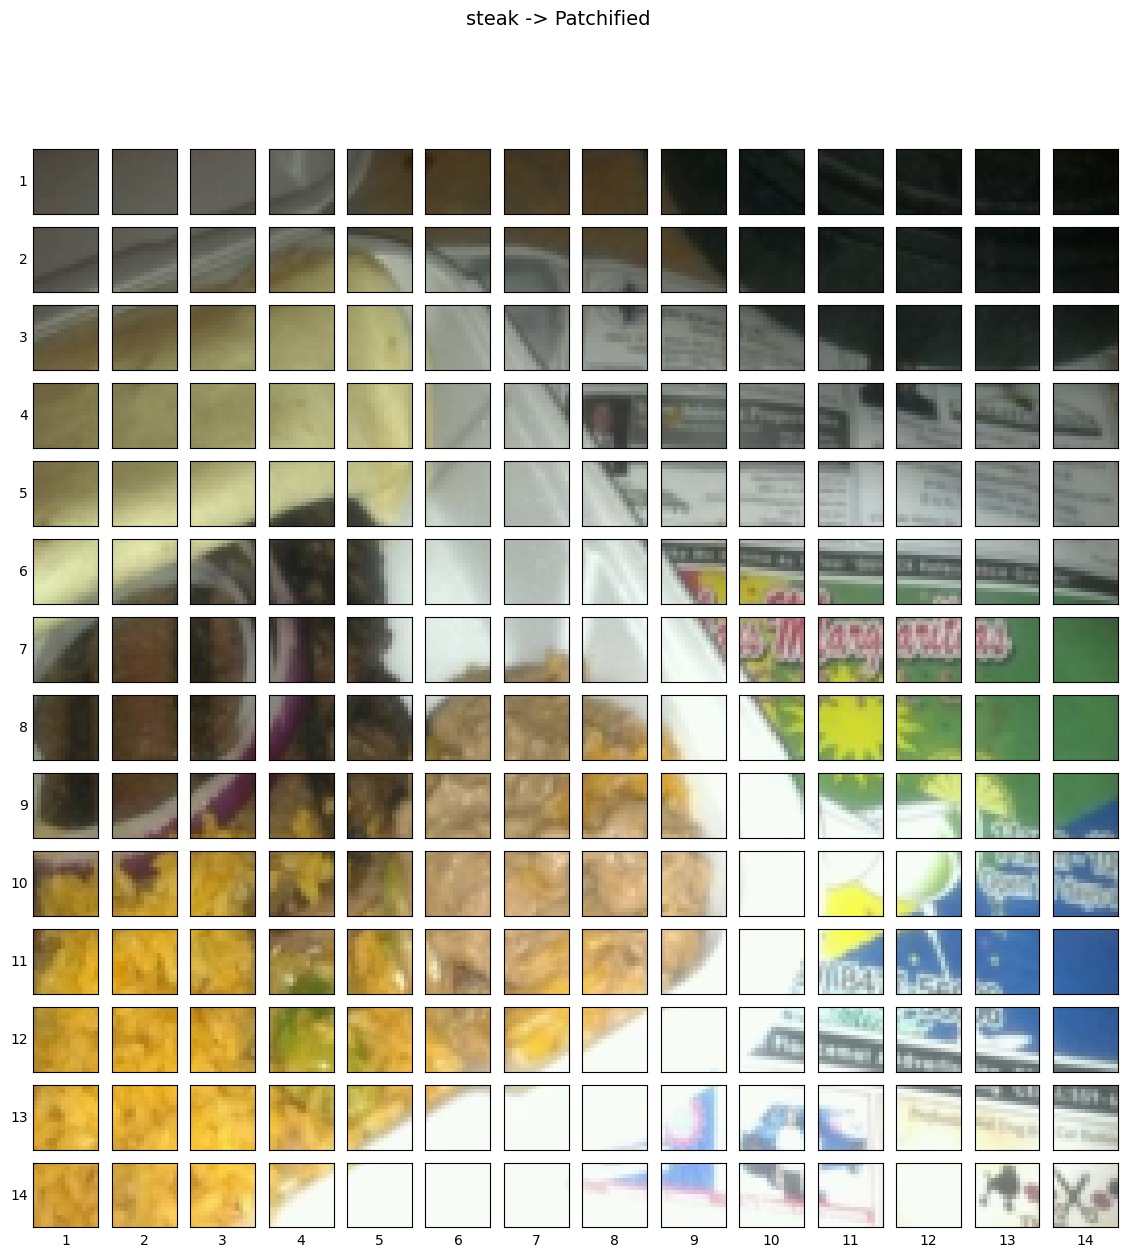

In [18]:
# Setup code to plot whole image as patches
img_size = 224
patch_size = 16
num_patches = img_size/patch_size
assert img_size % patch_size == 0, "Image size must be divisible by patch size"
print(f"Number of patches per row: {num_patches}\
  \nNumber of patches per column: {num_patches}\
  \nTotal patches: {num_patches*num_patches}\
  \nPatch size: {patch_size} pixels x {patch_size} pixels")

# Create a series of subplots
fig, axs = plt.subplots(nrows=img_size // patch_size,
                        ncols=img_size // patch_size,
                        figsize=(num_patches, num_patches),
                        sharex=True,
                        sharey=True)

# Loop through height and width of image
for i, patch_height in enumerate(range(0, img_size, patch_size)): # iterate through height
  for j, patch_width in enumerate(range(0, img_size, patch_size)):
    # Plot the permuted image on the different axes
    axs[i, j].imshow(image_permuted[patch_height:patch_height+patch_size, # iterate through height
                                    patch_width:patch_width+patch_size, # iterate through width
                                    :]) # get all color channels
    # Set up label information for each subplot (patch)
    axs[i, j].set_ylabel(i+1,
                         rotation="horizontal",
                         horizontalalignment="right",
                         verticalalignment="center")
    axs[i, j].set_xlabel(j+1)
    axs[i, j].set_xticks([])
    axs[i, j].set_yticks([])
    axs[i, j].label_outer()

# Set up a title for the plot
fig.suptitle(f"{class_names[label]} -> Patchified", fontsize=14)
plt.show()

### 4.3 Creating image patches and turning them into patch embeddings

Perhaps we could create the image patches and image patch embeddings in a single step using `torch.nn.Conv2d()` and setting the kernel size and stride parameters to `patch_size`

In [19]:
# Create conv2d layer to turn images into patches of learnable feature maps (embeddings)
from torch import nn

# Set the patch size
patch_size = 16

# Creating a conv2d layer
conv2d = nn.Conv2d(in_channels=3,
                   out_channels=768,
                   kernel_size=patch_size,
                   stride=patch_size,
                   padding=0)

conv2d

Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

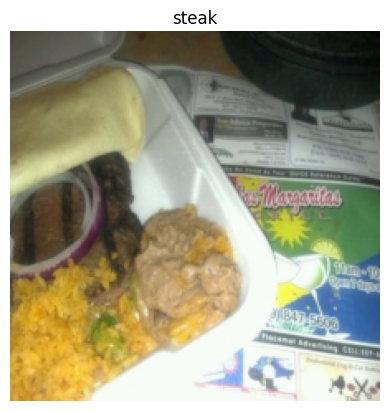

In [20]:
# View single image
plt.imshow(image_permuted)
plt.title(class_names[label])
plt.axis(False)

In [21]:
# Pass the image through the convolution layer
image_out_of_conv = conv2d(image.unsqueeze(0))
print(image_out_of_conv.shape)

torch.Size([1, 768, 14, 14])


In [22]:
image_out_of_conv.requires_grad

True

Showing random convolutional feature maps from indexes: [383, 415, 504, 292, 518]


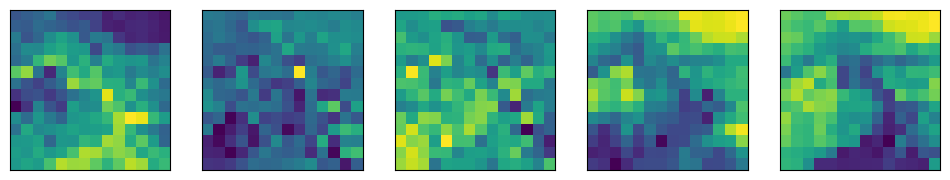

In [23]:
# plot random convolutional feature maps (embeddings)
import random
random_indexes = random.sample(range(0, 758), k = 5)
print(f"Showing random convolutional feature maps from indexes: {random_indexes}")

# Create plot
fig, axs = plt.subplots(nrows = 1, ncols = 5, figsize = (12,12))

# Plot random image feature maps
for i, idx in enumerate(random_indexes):
  image_conv_feature_map = image_out_of_conv[:, idx, :, :]
  axs[i].imshow(image_conv_feature_map.squeeze().detach().numpy())
  axs[i].set(xticklabels = [], yticklabels = [], xticks = [], yticks = [])

In [24]:
# Get a single feature map in tensor form
single_feature_map = image_out_of_conv[:,0,:,:]
single_feature_map, single_feature_map.requires_grad

(tensor([[[-1.0884e-01, -1.1211e-01, -1.3486e-01, -1.5001e-01, -1.5940e-01,
           -1.4002e-01, -1.3366e-01, -1.4701e-01, -4.0236e-02, -2.3431e-02,
           -2.5269e-02, -5.2649e-02, -1.8392e-02, -3.7335e-02],
          [-1.0659e-01, -1.6332e-01, -1.5271e-01, -2.0052e-01, -1.9779e-01,
           -1.1709e-01, -1.1347e-01, -1.5214e-01, -1.1227e-01, -4.0838e-02,
           -3.5586e-02, -3.4685e-02, -2.6754e-02, -3.3086e-02],
          [-1.6333e-01, -2.0891e-01, -1.9728e-01, -2.2847e-01, -2.5997e-01,
           -1.8478e-01, -1.5018e-01, -1.4164e-01, -1.5949e-01, -1.6020e-01,
           -7.2996e-02, -2.8876e-02, -3.3976e-02, -6.8300e-02],
          [-1.9554e-01, -2.2446e-01, -2.4343e-01, -2.5039e-01, -3.0007e-01,
           -1.5655e-01, -2.2312e-01, -1.5701e-01, -1.3041e-01, -1.1405e-01,
           -1.6880e-01, -5.6598e-02, -1.1090e-01, -1.3906e-01],
          [-2.1343e-01, -2.5846e-01, -2.9494e-01, -1.8111e-01, -2.1662e-01,
           -1.8413e-01, -1.8957e-01, -1.1558e-01, -1.8147e-0

### 4.4 Flattening the patch embedding with `torch.nn.Flatten()`

Right now we've a series of convolutional feature maps (patch embeddings) that we want to flatten into a sequence of patch embeddings to satisfy the input criteria of the ViT Transformer Encoder

In [25]:
print(f"{image_out_of_conv.shape} -> (batch_size, embedding_dim, feature_map_height, feature_map_width)")

torch.Size([1, 768, 14, 14]) -> (batch_size, embedding_dim, feature_map_height, feature_map_width)


In [26]:
from torch import nn
flatten_layer = nn.Flatten(start_dim = 2, end_dim=3)

flatten_layer(image_out_of_conv).shape

torch.Size([1, 768, 196])

Original Image Shape: torch.Size([3, 224, 224])
Image feature map (patches) shape: torch.Size([1, 768, 14, 14])
Flattened image feature map shape: torch.Size([1, 768, 196])


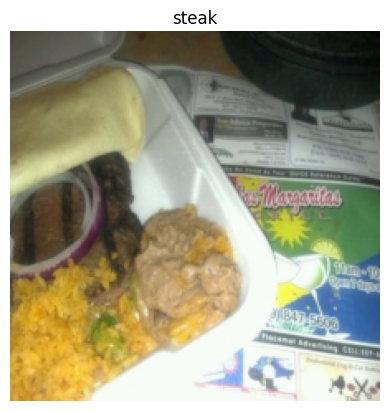

In [27]:
# Put everything together
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis(False);
print(f"Original Image Shape: {image.shape}")

# Turn images into feature maps
image_out_of_conv = conv2d(image.unsqueeze(0))
print(f"Image feature map (patches) shape: {image_out_of_conv.shape}")

# Flatten the feature maps
image_out_of_conv_flatten = flatten_layer(image_out_of_conv)
print(f"Flattened image feature map shape: {image_out_of_conv_flatten.shape}")

In [28]:
image_out_of_conv_flatten_permuted = image_out_of_conv_flatten.permute(0,2,1)
print(f"{image_out_of_conv_flatten_permuted.shape} -> (batch_size, number_of_patches, embedding_dimension)")

torch.Size([1, 196, 768]) -> (batch_size, number_of_patches, embedding_dimension)


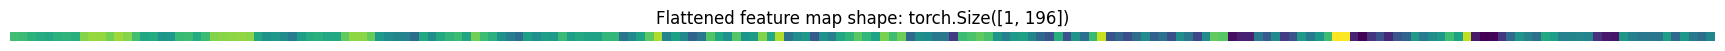

In [29]:
# Get a single flattened feature map
single_flattened_feature_map = image_out_of_conv_flatten_permuted[:, :, 0]

# Plot the flattened feature map visually
plt.figure(figsize=(22, 22))
plt.imshow(single_flattened_feature_map.detach().numpy())
plt.title(f"Flattened feature map shape: {single_flattened_feature_map.shape}")
plt.axis(False);

### 4.5 Turning the ViT patch embedding layer into a PyTorch module

We want this module to do a few things:
1. Create a class called `PatchEmbedding` that inherits from `nn.Module`.
2. Initialize with appropriate hyperparameters, such as channels, embedding dimension, patch size.
3. Create a layer to turn an image into embedded patches using `nn.Conv2d()`.
4. Create a layer to flatten the feature maps of the output of the layer in 3.
5. Define a `foward()` that defines the forward computation (e.g. pass through layer from 3 and 4).
6. Make sure the output shape of the layer reflects the required output shape of the patch embedding.

In [30]:
# 1. Create a class called PatchEmbedding
class PatchEmbedding(nn.Module):
  # 2. Initialize the layer with appropriate hyperparameters
  def __init__(self,
               in_channels: int = 3,
               patch_size: int = 16,
               embedding_dim:int = 768):
    super().__init__()

    self.patcher = nn.Conv2d(in_channels=in_channels,
                             out_channels=embedding_dim,
                             kernel_size=patch_size,
                             stride = patch_size,
                             padding=0)

    self.flatten = nn.Flatten(start_dim=2,end_dim=3)

  def forward(self, x):
    image_resolution = x.shape[-1]
    assert image_resolution % patch_size == 0, f"Input image must be divisible by patch size"

    x_patched = self.patcher(x.unsqueeze(0))
    print(f"Shape of x_patched: {x_patched.shape}")

    x_flattend = self.flatten(x_patched)
    print(f"Shape of x_flattened: {x_flattend.shape}")
    return x_flattend.permute(0,2,1)

In [31]:
set_seeds()

patchify = PatchEmbedding(in_channels=3,
                          patch_size=16,
                          embedding_dim=768)

print(f"Input image size: {image.unsqueeze(0).shape}")
patch_embedded_image = patchify(image)
print(f"Output patch embedding sequence shape: {patch_embedded_image.shape}")

Input image size: torch.Size([1, 3, 224, 224])
Shape of x_patched: torch.Size([1, 768, 14, 14])
Shape of x_flattened: torch.Size([1, 768, 196])
Output patch embedding sequence shape: torch.Size([1, 196, 768])


### 4.6 Creating the class token embedding
Want to: prepend a learnable class token to start of the patch embedding

In [32]:
patch_embedded_image

tensor([[[-0.3383,  0.0881, -0.1238,  ...,  0.2438, -0.1362,  0.1098],
         [-0.3774,  0.1005, -0.1400,  ...,  0.2759, -0.1507,  0.1290],
         [-0.3766,  0.0944, -0.1285,  ...,  0.2899, -0.1691,  0.1418],
         ...,
         [-1.0178,  0.2781, -0.2893,  ...,  0.7764, -0.4582,  0.3570],
         [-0.5787,  0.2974, -0.2304,  ...,  0.7170, -0.4884,  0.2733],
         [-0.8250,  0.1490, -0.1786,  ...,  0.6803, -0.5088,  0.2638]]],
       grad_fn=<PermuteBackward0>)

In [33]:
# Get the batch size and the embedding size
batch_size = patch_embedded_image.shape[0]
embedding_dimension = patch_embedded_image.shape[-1]
batch_size, embedding_dimension


(1, 768)

In [34]:
# Create class token as a learnable parameter that shares the same size as the embedding dimesion (D)
class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimension),
                           requires_grad=True)

class_token.shape

torch.Size([1, 1, 768])

In [35]:
# Add the class token embedding to the front of the patch embedding
patch_embedded_image_with_class_embedding = torch.cat((class_token, patch_embedded_image), dim = 1)

print(patch_embedded_image_with_class_embedding)
print(f"Sequence of patch embeddings with class token prepended shape: {patch_embedded_image_with_class_embedding.shape} -> (batch_size, class_token + number_of_patches, embedding_dim)")


tensor([[[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
         [-0.3383,  0.0881, -0.1238,  ...,  0.2438, -0.1362,  0.1098],
         [-0.3774,  0.1005, -0.1400,  ...,  0.2759, -0.1507,  0.1290],
         ...,
         [-1.0178,  0.2781, -0.2893,  ...,  0.7764, -0.4582,  0.3570],
         [-0.5787,  0.2974, -0.2304,  ...,  0.7170, -0.4884,  0.2733],
         [-0.8250,  0.1490, -0.1786,  ...,  0.6803, -0.5088,  0.2638]]],
       grad_fn=<CatBackward0>)
Sequence of patch embeddings with class token prepended shape: torch.Size([1, 197, 768]) -> (batch_size, class_token + number_of_patches, embedding_dim)


### 4.7 Creating the position embedding

Want to: Create a series of 1D learnable position embeddings and to add them to the sequence of patch embeddings.

In [36]:
# View the sequence of patch embeddings with the prepended class embedding
patch_embedded_image_with_class_embedding, patch_embedded_image_with_class_embedding.shape

(tensor([[[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
          [-0.3383,  0.0881, -0.1238,  ...,  0.2438, -0.1362,  0.1098],
          [-0.3774,  0.1005, -0.1400,  ...,  0.2759, -0.1507,  0.1290],
          ...,
          [-1.0178,  0.2781, -0.2893,  ...,  0.7764, -0.4582,  0.3570],
          [-0.5787,  0.2974, -0.2304,  ...,  0.7170, -0.4884,  0.2733],
          [-0.8250,  0.1490, -0.1786,  ...,  0.6803, -0.5088,  0.2638]]],
        grad_fn=<CatBackward0>),
 torch.Size([1, 197, 768]))

In [37]:
# Caluclate N (number_of_patches)
number_of_patches = int((height * width) / patch_size**2 )

# Get the embedding dimension
embedding_dimension = patch_embedded_image_with_class_embedding.shape[-1]

# Create3 the learnable 1D psitional embedding
position_embedding = nn.Parameter(torch.ones(1,
                                             number_of_patches+1,
                                             embedding_dimension),
                                  requires_grad=True)

position_embedding, position_embedding.shape

(Parameter containing:
 tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]]], requires_grad=True),
 torch.Size([1, 197, 768]))

In [38]:
# Add the position embedding to patch and class token embedding
patch_and_position_embedding = patch_embedded_image_with_class_embedding + position_embedding
print(patch_and_position_embedding)
print(f"Patch and position embedding shape: {patch_and_position_embedding.shape}")

tensor([[[ 2.0000,  2.0000,  2.0000,  ...,  2.0000,  2.0000,  2.0000],
         [ 0.6617,  1.0881,  0.8762,  ...,  1.2438,  0.8638,  1.1098],
         [ 0.6226,  1.1005,  0.8600,  ...,  1.2759,  0.8493,  1.1290],
         ...,
         [-0.0178,  1.2781,  0.7107,  ...,  1.7764,  0.5418,  1.3570],
         [ 0.4213,  1.2974,  0.7696,  ...,  1.7170,  0.5116,  1.2733],
         [ 0.1750,  1.1490,  0.8214,  ...,  1.6803,  0.4912,  1.2638]]],
       grad_fn=<AddBackward0>)
Patch and position embedding shape: torch.Size([1, 197, 768])


### 4.8 Putting it all together: from image to embedding
We've written code to turn an image into a flattened sequence of patch embeddings.

now let's it all in one cell

In [39]:
# Set seed
set_seeds()

# 1. Set the patch_size
patch_size = 16

# 2. Print the shapes of the original image tensors and get the image dimmensions
print(f"Image tensor shape: {image.shape}")
height, width = image.shape[1], image.shape[2]

# 3. Get image tensor and add a batch dimension
x = image.unsqueeze(0)
print(f"Input image shape: {x.shape}")

# 4. Create patch embedding layer
patch_embedding_layer = PatchEmbedding(in_channels=3,
                                       patch_size=patch_size,
                                       embedding_dim=768)

# 5. Pass input image through patch embedding layer
patch_embedding = patch_embedding_layer(x.squeeze(0))
print(f"Patch embedding shape: {patch_embedding.shape}")

# 6. Create the class token
batch_size = patch_embedding.shape[0]
embedding_dimmension = patch_embedding.shape[-1]
class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimmension))
print(f"Class token embedding shape: {class_token.shape}")

# 7. Prepend the class token embeding to patch embedding
patch_embedding_class_token = torch.cat((class_token, patch_embedding), dim =1)
print(f"Patch embedding with class token shape: {patch_embedded_image_with_class_embedding.shape}")

# 8. Create position embedding
number_of_patches = int((height*width) / patch_size**2)
position_embedding = nn.Parameter(torch.ones(1, number_of_patches+1, embedding_dimension))

# 9. Add the position embedding to patch embedding with class token
patch_add_position_embedding = patch_embedding_class_token + position_embedding
print(f"Patch and position embedding shape: {patch_add_position_embedding.shape}")

Image tensor shape: torch.Size([3, 224, 224])
Input image shape: torch.Size([1, 3, 224, 224])
Shape of x_patched: torch.Size([1, 768, 14, 14])
Shape of x_flattened: torch.Size([1, 768, 196])
Patch embedding shape: torch.Size([1, 196, 768])
Class token embedding shape: torch.Size([1, 1, 768])
Patch embedding with class token shape: torch.Size([1, 197, 768])
Patch and position embedding shape: torch.Size([1, 197, 768])


In [40]:
class PatchEmbedding(nn.Module):
  def __init__(self,
               in_channels: int = 3,
               patch_size: int = 16,
               embedding_dimension: int = 768,
               height: int = 224,
               width: int = 224,
               batch_size: int = 1,
              #  device = device # Adding device in init
               ):

    super().__init__()

    self.batch_size = batch_size
    self.embedding_dimension = embedding_dimension
    # Assigning device if available
    # self.device = device if device else ("cuda" if torch.cuda.is_available() else "cpu")

    self.patcher = nn.Conv2d(in_channels=in_channels,
                             out_channels=embedding_dimension,
                             kernel_size=patch_size,
                             stride = patch_size,
                             padding = 0,
                             device=device)

    self.flatten = nn.Flatten(start_dim=2, end_dim = 3)

    # Initialize positional embeddings on the specified device
    num_patches = int((height * width) / patch_size**2)
    # Moving position_embedding initialization to device
    self.position_embedding = nn.Parameter(torch.ones(1, num_patches + 1, embedding_dimension, device = device), requires_grad=True)


  def forward(self, x):
    if len(x.shape) == 4:

      # Patching the image into its respected patch size
      patched_image = self.patcher(x)

      # Flattened the image and then rearranged the dimension positions
      flattened_image = self.flatten(patched_image)
      flattened_image = flattened_image.permute(0,2,1)

      # Creating the class parameter (class_token)
      # Moving class_token initialization to device
      batch_size = x.shape[0]
      class_token = nn.Parameter(torch.ones(batch_size, 1, self.embedding_dimension, device = device), requires_grad=True)

      # Adding the class token to the flattened vector
      print(f"Flattened Image: {flattened_image.device}")
      image_with_class_token = torch.cat((class_token, flattened_image), dim = 1)
      # print(f"Class_token: {class_token.device}\n Flattened_image: {flattened_image.device}")
      # Adding the positional vector to the image with class tokens
      vector_embedding = image_with_class_token + self.position_embedding


      # print(f"Vector Embedding shape: {vector_embedding.shape}")

      return vector_embedding

    elif len(x.shape) == 3:
      print(f"Image does not have batch dimmension | adding one...")
      x = x.unsqueeze(0)
      return self.forward(x)

In [41]:
patchify = PatchEmbedding()
random_image = torch.rand(1,3,224,224)
output_image = patchify(random_image.to(device))
print(f"Output image dimmensions: {output_image.shape}")

Flattened Image: cuda:0
Output image dimmensions: torch.Size([1, 197, 768])


## 5. Equation 2: Multihead Self-Attention (MSA block)

* **Multihead self-attention** = which part of a sequence should pay the most attention to itself?
  * In our case, we have a series of embedded image patches, which patch significantly relates to another patch.
  * We want our neural network (ViT) to learn this relationship/representation.
* To replicate MSA in PyTorch we can use: https://pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html

* **LayerNorm** = Layer normalization (LayerNorm) is a technique to normalize the distributions of intermediate layers. It enables smoother gradients, faster training, and better generalization accuracy.
  * Normalization = make everything have the same mean and same standard deviation.
  * In PyTorch = https://pytorch.org/docs/stable/generated/torch.nn.LayerNorm.html, normalizes values over $D$ dimension, in our case, the $D$ dimension is the embedding dimension.
    * When we normalize along the embedding dimension, it's like making all of the stairs in a staircase the same size.

In [42]:
class MultiHeadSelfAttentionBlock(nn.Module):
  """Creates a multi-head self-attention block ("MSA block" for short).
  """
  def __init__(self,
               embedding_dim:int=768, # Hidden size D (embedding dimension) from Table 1 for ViT-Base
               num_heads:int=12, # Heads from Table 1 for ViT-Base
               attn_dropout:int=0):
    super().__init__()

    # Create the norm layer (LN)
    self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim, device = device)

    # Create multihead attention (MSA) layer
    self.multihead_attn = nn.MultiheadAttention(embed_dim=embedding_dim,
                                                num_heads=num_heads,
                                                dropout=attn_dropout,
                                                batch_first=True) # is the batch first? (batch, seq, feature) -> (batch, number_of_patches, embedding_dimension)

  def forward(self, x):
    x = self.layer_norm(x)
    attn_output, _ = self.multihead_attn(query=x,
                                         key=x,
                                         value=x,
                                         need_weights=False)
    return attn_output

In [43]:
# # Create an instance MSA block
# multihead_self_attention_block = MultiHeadSelfAttentionBlock(embedding_dim=768,
#                                                              num_heads=12,
#                                                              attn_dropout=0)

# # Pass the patch and position image embedding sequence through MSA block
# patched_image_through_msa_block = multihead_self_attention_block(patch_and_position_embedding)
# print(f"Input shape of MSA block: {patch_and_position_embedding.shape}")
# print(f"Output shape of MSA block: {patched_image_through_msa_block.shape}")

## 6. Equation 3: Multilayer Perceptron (MLP block)

* **MLP** = The MLP contains two layers with a GELU non-linearity (section 3.1).
  * MLP = a quite broad term for a block with a series of layer(s), layers can be multiple or even only one hidden layer.
  * Layers can mean: fully-connected, dense, linear, feed-forward, all are often similar names for the same thing. In PyTorch, they're often called `torch.nn.Linear()` and in TensorFlow they might be called `tf.keras.layers.Dense()`
  * GELU in PyTorch - https://pytorch.org/docs/stable/generated/torch.nn.GELU.html#torch.nn.GELU
  * MLP number of hidden units = MLP Size in Table 1
* **Dropout** =  Dropout, when used, is applied after
every dense layer except for the the qkv-projections and directly after adding positional- to patch
embeddings. Hybrid models are trained with the exact setup as their ViT counterparts.
  * Value for Dropout available in Table 3

In pseudocode:

```python
# MLP
x = linear -> non-linear -> dropout -> linear -> dropout
```

In [44]:
class MLPBlock(nn.Module):
  def __init__(self,
               embedding_dim:int=768,
               mlp_size:int=3072,
               dropout:int=0.1):
    super().__init__()

    # Create the norm layer (LN)
    self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim,device=device)

    # Create the MLP
    self.mlp = nn.Sequential(
        nn.Linear(in_features=embedding_dim,
                  out_features=mlp_size),
        nn.GELU(),
        nn.Dropout(p=dropout),
        nn.Linear(in_features=mlp_size,
                  out_features=embedding_dim),
        nn.Dropout(p=dropout)
    )

  def forward(self, x):
    x = self.layer_norm(x)
    x = self.mlp(x)
    return x
    # return self.mlp(self.layer_norm(x)) # same as above

In [45]:
# # Create an instance of MLPBlock
# mlp_block = MLPBlock(embedding_dim=768,
#                      mlp_size=3072,
#                      dropout=0.1)

# # Pass output the MSABlock through MLPBlock
# patched_image_through_mlp_block = mlp_block(patched_image_through_msa_block)
# print(f"Input shape of MLP block: {patched_image_through_msa_block.shape}")
# print(f"Output shape of MLP block: {patched_image_through_mlp_block.shape}")

## 7. Creating the Transformer Encoder

The Transformer Encoder is a combination of alternating blocks of MSA (equation 2) and MLP (equation 3).

And there are residual connections between each block.

* Encoder = turn a sequence into learnable representation
* Decoder = go from learn representation back to some sort of sequence
* Residual connections = add a layer(s) input to its subsequent output, this enables the creation of deeper networks (prevents weights from getting too small)

In pseudocode:

```python
# Transformer Encoder
x_input -> MSA_block -> [MSA_block_output + x_input] -> MLP_block -> [MLP_block_output + MSA_block_output + x_input] -> ...
```

### 7.1 Create a custom Transformer Encoder block

In [46]:
class TransformerEncoderBlock(nn.Module):
  def __init__(self,
               embeddin_dim: int = 768,
               num_heads: int = 12,
               mlp_size: int = 3072,
               mlp_dropout: int = 0.1,
               attn_dropout: int = 0):
    super().__init__()

    # Create MSA block (equation 2)
    self.msa_block = MultiHeadSelfAttentionBlock(embedding_dim = embeddin_dim,
                                                 num_heads=num_heads,
                                                 attn_dropout=attn_dropout)

    # Create the MLP block (equation 3)
    self.mlp_block = MLPBlock(embedding_dim=embeddin_dim,
                              mlp_size=mlp_size,
                              dropout=mlp_dropout)

  def forward(self, x):
    x = self.msa_block(x) + x
    x = self.mlp_block(x) + x
    return x

In [47]:
# Create an instance of the transformer block
transformer_encoder_block = TransformerEncoderBlock()

# Get the summary of the model using torchinfo
summary(model = transformer_encoder_block,
        input_size=(1, 197, 768),
        col_names=['input_size','output_size', 'num_params','trainable'],
        col_width = 20,
        row_settings=['var_names'])

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
TransformerEncoderBlock (TransformerEncoderBlock)  [1, 197, 768]        [1, 197, 768]        --                   True
├─MultiHeadSelfAttentionBlock (msa_block)          [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layer_norm)                      [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─MultiheadAttention (multihead_attn)         --                   [1, 197, 768]        2,362,368            True
├─MLPBlock (mlp_block)                             [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layer_norm)                      [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─Sequential (mlp)                            [1, 197, 768]        [1, 197, 768]        --                   True
│    │    └─Linear (0)                     

### 7.2 Create a Transformer Encoder layer with in-built PyTorch layers

So far we've created a transformer encoder by hand.

But because of how good the Transformer architecture is, PyTorch has implemented ready to use Transformer Encoder layers: https://pytorch.org/docs/stable/nn.html#transformer-layers

We can create a Transformer Encoder with pure PyTorch layers: https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoderLayer.html#torch.nn.TransformerEncoderLayer

In [48]:
# Create teh same as above with torch.nn.TransformerEncoderLayer
torch_transformer_encoder_layer = nn.TransformerEncoderLayer(d_model = 768,
                                                             nhead = 12,
                                                             dim_feedforward=3072,
                                                             dropout = 0.1,
                                                             activation='gelu',
                                                             batch_first=True,
                                                             norm_first=True)

torch_transformer_encoder_layer

TransformerEncoderLayer(
  (self_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
  )
  (linear1): Linear(in_features=768, out_features=3072, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (linear2): Linear(in_features=3072, out_features=768, bias=True)
  (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (dropout1): Dropout(p=0.1, inplace=False)
  (dropout2): Dropout(p=0.1, inplace=False)
)

In [49]:
# Get the summary of the torch_transformer_encoder_laye
summary(model = torch_transformer_encoder_layer,
        input_size = (1, 197, 768),
        col_names=['input_size','output_size','num_params','trainable'],
        col_width = 20,
        row_settings=['var_names'])

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
TransformerEncoderLayer (TransformerEncoderLayer)  [1, 197, 768]        [1, 197, 768]        --                   True
├─LayerNorm (norm1)                                [1, 197, 768]        [1, 197, 768]        1,536                True
├─MultiheadAttention (self_attn)                   [1, 197, 768]        [1, 197, 768]        2,362,368            True
├─Dropout (dropout1)                               [1, 197, 768]        [1, 197, 768]        --                   --
├─LayerNorm (norm2)                                [1, 197, 768]        [1, 197, 768]        1,536                True
├─Linear (linear1)                                 [1, 197, 768]        [1, 197, 3072]       2,362,368            True
├─Dropout (dropout)                                [1, 197, 3072]       [1, 197, 3072]       --                   --
├─Linear (linear2)                             

## 8. Putting it all together to create ViT

In [50]:
# class ViT(nn.Module):
#   def __init__(self,
#                img_size: int = 224,
#                in_channels: int = 3,
#                patch_size: int = 16,
#                num_transformer_layers: int = 12,
#                embedding_dim: int = 768,
#                mlp_size: int = 3072,
#                num_heads: int = 12,
#                attn_dropout: int = 0,
#                mlp_dropout: int = 0.1,
#                embedding_dropout: int = 0.1,
#                num_classes: int = 1000):
#     super().__init__()

#     # make an assertion that the image size is comptable with the patch size
#     assert img_size % patch_size == 0, f"Image size must be divisible by patch size , image: {img_size}, patch_size: {patch_size}"

#     # Calculate the number of patches (height * width / patch^2)
#     self.num_patches = (img_size * img_size) / patch_size**2

#     # Create learnable class embeddings (needs to go at front of sequence of patch embeddings)
#     # self.class_embedding = nn.Parameter(data = torch.randn(1,1,embedding_dim)) Don't need this as the modified PatchEmbedding layer already does this in my case

#     # Create learnable position embedding
#     # self.position_embedding = nn.Parmeter(data = torch.randn(1, num_patches, embedding_dim))  Don't need this as the modified PatchEmbedding layer already does this in my case

#     # Create embedding dropout
#     self.embedding_dropout = nn.Dropout(p = embedding_dropout)

#     # Create patch embedding layer
#     self.patch_embedding = PatchEmbedding(in_channels = in_channels,
#                                           patch_size=patch_size,
#                                           embedding_dimension=embedding_dim)

#     # Create the transformer encoder block
#     self.transformer_encoder = nn.Sequential(*[TransformerEncoderBlock(embeddin_dim = embedding_dim,
#                                                                        num_heads = num_heads,
#                                                                        mlp_size = mlp_size,
#                                                                        mlp_dropout=mlp_dropout) for _ in range(num_transformer_layers)])

#     # Create classifier head
#     self.classifier = nn.Sequential(
#         nn.LayerNorm(normalized_shape=embedding_dim),
#         nn.Linear(in_features = embedding_dim,
#                   out_features=num_classes)
#     )

#   def forward(self,x):
#     # Get the batch size
#     batch_size = x.shape[0]

#     # print(f"Initial: {x.device}")
#     # Get the image ready, by making sure to have the image patched and then have the class tokens pre-appended and the position embedding attached
#     x = self.patch_embedding(x)
#     # print(f"After patch embedding: {x.device}")

#     # Apply the dropout to patch embedding("directly after adding positional - to patch embedding")
#     x = self.embedding_dropout(x)
#     # print(f"After embedding_dropout: {x.device}")

#     # Pass positional and patch embedding to Transformer Encoder (equation 2 & 3)
#     x = self.transformer_encoder(x)
#     # print(f"After transformer encoder: {x.device}")


#     # Put the oth index logit throught classifier (equation 4)
#     x = self.classifier(x[:, 0])

#     return x


In [51]:
# set_seeds()

# # Create a random image with tensor with same shape as a single image
# random_image_tensor = torch.randn(1,3,224,224)

# # Create an instance of ViT with the number of classes we're woking with (pizza, steak and sushi)
# vit = ViT(num_classes=len(class_names))

# # Pass the random image tensor to our ViT instance
# vit(random_image_tensor.to(device))

### 8.1 Getting a visula summary of our ViT model

In [52]:
# vit(random_image_tensor)

In [53]:
from torchinfo import summary

# vit = ViT(num_classes = 1000)
# vit = vit.cpu()

# summary(model=ViT(num_classes=len(class_names)),
#         input_size=(1, 3, 224, 224), # (batch_size, color_channels, height, width)
#         col_names=["input_size", "output_size", "num_params", "trainable"],
#         col_width=20,
#         row_settings=["var_names"],
#         device = 'cpu')

# Recreating the ViT architecture once again

In [54]:
# 1. Create patch Embeddings layer
class PatchEmbedding1(nn.Module):
  def __init__(self,
               in_channels: int = 3,
               height: int = 224,
               width: int = 224,
               patch_size: int = 16,
               embedding_dim: int = 768):
    super().__init__()

    self.num_patches = int((height * width) / patch_size**2)
    self.embedding_dim = embedding_dim

    self.patch_size = patch_size

    self.num_patches = int((height*width) / patch_size**2)

    self.patcher = nn.Conv2d(in_channels=in_channels,
                             out_channels=embedding_dim,
                             kernel_size=patch_size,
                             stride = patch_size,
                             padding = 0)


    self.flatten = nn.Flatten(start_dim = 2, end_dim = 3)

  def forward(self, x):
    batch_size = x.shape[0]

    x_patched = self.patcher(x)

    x_flattened = self.flatten(x_patched)

    x_flattened = x_flattened.permute(0,2,1)

    class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimension), requires_grad=True).to(device)

    x_flattened_class_tokens = torch.cat((class_token, x_flattened), dim = 1)

    positional_embedding = nn.Parameter(torch.ones(1, self.num_patches + 1, self.embedding_dim)).to(device)

    x_patched_class_position = x_flattened_class_tokens + positional_embedding

    return x_patched_class_position

In [55]:
# 2. Multi Head Self Attention Block
class MultiHeadSelfAttentionBlock(nn.Module):
  """ Creates a multi-head self-attention block ("MSA block" for short) """

  def __init__(self,
               embedding_dim: int = 768,
               num_heads: int = 12,
               attn_dropout: int = 0):
    super().__init__()

    self.layer_norm = nn.LayerNorm(normalized_shape = embedding_dim)

    self.multihead_attn = nn.MultiheadAttention(embed_dim = embedding_dim,
                                                num_heads = num_heads,
                                                dropout = attn_dropout,
                                                batch_first = True)

  def forward(self, x):
    x = self.layer_norm(x)

    attn_dropout, _ = self.multihead_attn(query = x,
                                          key = x,
                                          value = x,
                                          need_weights = False)



    return attn_dropout

In [56]:
# 3. MLP (Multi Layer Perceptron) Block

class MLPBlock(nn.Module):
  def __init__(self,
               embedding_dim:int = 768,
               mlp_size: int = 3072,
               dropout: int = 0.1):
    super().__init__()

    self.layer_norm = nn.LayerNorm(normalized_shape = embedding_dim)

    self.mlp = nn.Sequential(
        nn.Linear(in_features = embedding_dim, out_features = mlp_size),
        nn.GELU(),
        nn.Dropout(p = dropout),

        nn.Linear(in_features = mlp_size, out_features = embedding_dim),
        nn.Dropout(p = dropout)
    )


  def forward(self, x):
    return self.mlp(self.layer_norm(x))

In [57]:
# 4. Creating the transformer encoder block

# ipython-input-58-76dfbb688004
class TransformerEncoderBlock(nn.Module):
  def __init__(self,
               embedding_dim: int = 768, # Changed "embeddin_dim" to "embedding_dim"
               num_heads: int = 12,
               mlp_size: int = 3072,
               attn_dropout: int = 0,
               mlp_dropout: int = 0.1):
    super().__init__()

    self.msa = MultiHeadSelfAttentionBlock(embedding_dim = embedding_dim,
                                           num_heads = num_heads,
                                           attn_dropout = attn_dropout)

    self.mlp = MLPBlock(embedding_dim = embedding_dim,
                        mlp_size = mlp_size,
                        dropout = mlp_dropout)

  def forward(self, x):
    x = self.msa(x) + x
    x = self.mlp(x) + x
    return x

In [58]:
class ViT(nn.Module):
  def __init__(self,
               in_channels: int = 3,
               height: int = 224,
               width: int = 224,
               patch_size: int = 16,
               embedding_dim: int = 768,
               num_transformer_layers: int = 12,
               num_heads: int = 12,
               mlp_size: int = 3072,
               attn_dropout: int = 0,
               mlp_dropout: int = 0.1,
               num_classes: int = 1000):
    super().__init__()

    self.patch_embedding = PatchEmbedding1(in_channels = in_channels,
                                           height = height,
                                           width = width,
                                           patch_size = patch_size,
                                           embedding_dim = embedding_dim)

    self.transformer_encoder = nn.Sequential(*[TransformerEncoderBlock(embedding_dim = embedding_dim,
                                                                       num_heads = num_heads,
                                                                       mlp_size = mlp_size,
                                                                       attn_dropout = attn_dropout,
                                                                       mlp_dropout = mlp_dropout) for _ in range(num_transformer_layers)])

    self.classifier = nn.Sequential(
        nn.LayerNorm(normalized_shape = embedding_dim),
        nn.Linear(in_features = embedding_dim, out_features = num_classes)
    )

  def forward(self, x):
    x = self.patch_embedding(x)
    x = self.transformer_encoder(x)
    x = self.classifier(x[:,0])
    return x


In [59]:
from torchinfo import summary

summary(model=ViT(num_classes=len(class_names)),
        input_size=(1, 3, 224, 224), # (batch_size, color_channels, height, width)
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
ViT (ViT)                                                    [1, 3, 224, 224]     [1, 3]               --                   True
├─PatchEmbedding1 (patch_embedding)                          [1, 3, 224, 224]     [1, 197, 768]        --                   True
│    └─Conv2d (patcher)                                      [1, 3, 224, 224]     [1, 768, 14, 14]     590,592              True
│    └─Flatten (flatten)                                     [1, 768, 14, 14]     [1, 768, 196]        --                   --
├─Sequential (transformer_encoder)                           [1, 197, 768]        [1, 197, 768]        --                   True
│    └─TransformerEncoderBlock (0)                           [1, 197, 768]        [1, 197, 768]        --                   True
│    │    └─MultiHeadSelfAttentionBlock (msa)                [1, 197, 768]        [1, 197, 768

## 9. Setting up training code for our custom ViT

We've replicated the ViT architecture, now let's see how it performs on our FoodVision Mini data.

### 9.1 Creating an optimizer

The paper states it uses the Adam optimizer (section 4, Training & fine-tuning) with $B1$ value of 0.9, $B2$ of 0.999 (defaults) and a weight decay of 0.1.

Weight decay = Weight decay is a regularization technique by adding a small penalty, usually the L2 norm of the weights (all the weights of the model), to the loss function.

Regularization technique = prevents overfitting.

In [60]:
# vit

In [61]:
optimizer = torch.optim.Adam(vit.parameters(),
                             lr = 0.001,
                              weight_decay = 0.1)

NameError: name 'vit' is not defined

### 9.2 Creating a loss function

The ViT paper doesn't actually mention what loss function they used.

So since it's a multi-class classification we'll use the `torch.nn.CrossEntropyLoss()`.

### 9.3 Training our ViT Model

In [62]:
from going_modular.going_modular import engine

set_seeds()

vit1 = ViT(num_classes=len(class_names))

optimizer = torch.optim.Adam(vit1.parameters(),
                             lr = 0.001,
                             weight_decay=0.1)


loss_fn = torch.nn.CrossEntropyLoss()

results = engine.train(model = vit1,
                       train_dataloader= train_dataloader,
                       test_dataloader = test_dataloader,
                       epochs = 10,
                       optimizer = optimizer,
                       loss_fn = loss_fn,
                       device = device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 3.6355 | train_acc: 0.3906 | test_loss: 1.0990 | test_acc: 0.5417
Epoch: 2 | train_loss: 1.3321 | train_acc: 0.2812 | test_loss: 1.1166 | test_acc: 0.5417
Epoch: 3 | train_loss: 1.4272 | train_acc: 0.2266 | test_loss: 1.0723 | test_acc: 0.5417
Epoch: 4 | train_loss: 1.2914 | train_acc: 0.4102 | test_loss: 1.2170 | test_acc: 0.2604
Epoch: 5 | train_loss: 1.1067 | train_acc: 0.4102 | test_loss: 2.2224 | test_acc: 0.2604
Epoch: 6 | train_loss: 1.5348 | train_acc: 0.3359 | test_loss: 1.6299 | test_acc: 0.5417
Epoch: 7 | train_loss: 1.5791 | train_acc: 0.4219 | test_loss: 1.4922 | test_acc: 0.5417
Epoch: 8 | train_loss: 1.4123 | train_acc: 0.4180 | test_loss: 1.4436 | test_acc: 0.2604
Epoch: 9 | train_loss: 1.2272 | train_acc: 0.3828 | test_loss: 1.5679 | test_acc: 0.1979
Epoch: 10 | train_loss: 1.1544 | train_acc: 0.3203 | test_loss: 1.2064 | test_acc: 0.2604


### 9.4 What our training setup is missing

How is our training setup different to the ViT paper?

We've replicated model archirecture correctly.

But what was different between our training procedure (to get such poor results) and the ViT paper training procedure to get such great results?

The main things our training implementation is missing:

Prevent underfitting:
* Data - our setup uses far less data (225 vs millions)

Prevent overfitting:
* Learning rate warmup - start with a low learning rate and increase to a base LR
* Learning rate decay - as your model gets closer to convergence, start to lower the learning rate
* Gradient clipping - prevent gradients from getting too big

Search "pytorch [technique name]"

### 9.5 Plotting loss curves for our model

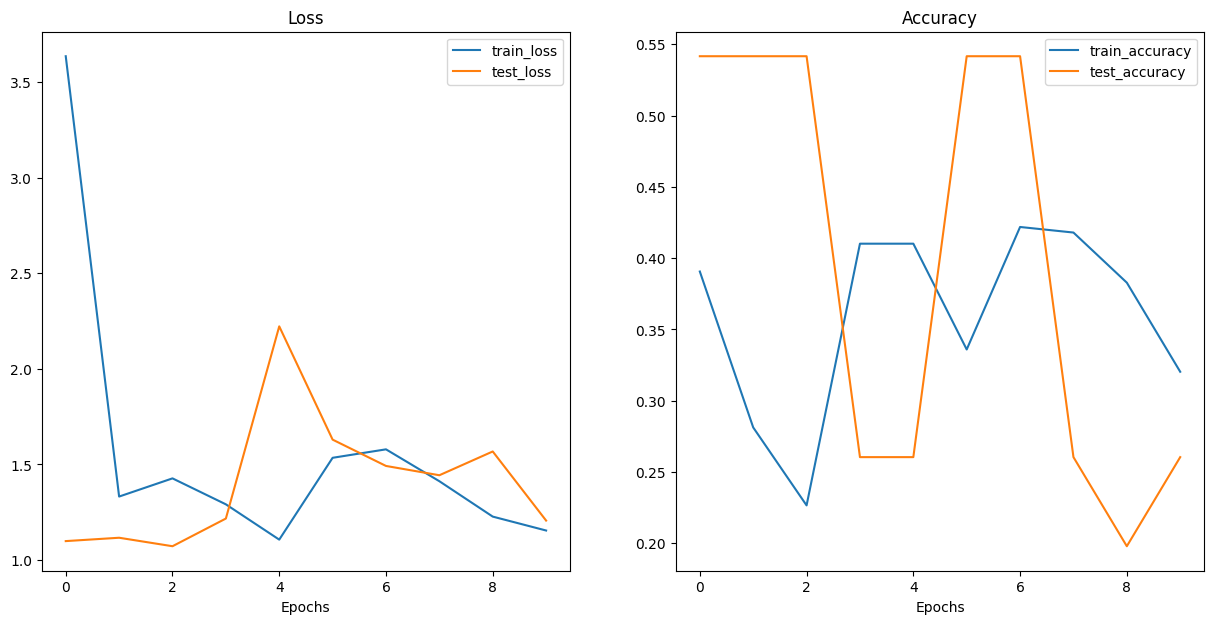

In [63]:
from helper_functions import plot_loss_curves

plot_loss_curves(results)

### Transfer learning

## 10. Using a pretrained ViT from `torchvision.models`

Generally, in deep learning if you can use a pretrained model from a large dataset on your own problem, it's often a good place to start.

If you can find a pretrained model and use transfer learning, give it a go, it often achieves great results with little data.

### 10.1 Why use a pretrained model?

* Sometimes data is limited
* Limited training resources
* Get better results faster (sometimes)...

In [64]:
weights = torchvision.models.ViT_B_16_Weights.DEFAULT
vit2 = torchvision.models.vit_b_16(weights=weights).to(device)

vit2

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:02<00:00, 166MB/s]


VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [65]:
from torchinfo import summary

summary(model=vit2,
        input_size=(1, 3, 224, 224), # (batch_size, color_channels, height, width)
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [1, 3, 224, 224]     [1, 1000]            768                  True
├─Conv2d (conv_proj)                                         [1, 3, 224, 224]     [1, 768, 14, 14]     590,592              True
├─Encoder (encoder)                                          [1, 197, 768]        [1, 197, 768]        151,296              True
│    └─Dropout (dropout)                                     [1, 197, 768]        [1, 197, 768]        --                   --
│    └─Sequential (layers)                                   [1, 197, 768]        [1, 197, 768]        --                   True
│    │    └─EncoderBlock (encoder_layer_0)                   [1, 197, 768]        [1, 197, 768]        7,087,872            True
│    │    └─EncoderBlock (encoder_layer_1)                   [1, 197, 768]        [1, 197, 768

In [66]:
for params in vit2.parameters():
  params.requires_grad = False

vit2.heads = nn.Linear(in_features=768, out_features=len(class_names)).to(device)

In [67]:
from torchinfo import summary

summary(model=vit2,
        input_size=(1, 3, 224, 224), # (batch_size, color_channels, height, width)
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [1, 3, 224, 224]     [1, 3]               768                  Partial
├─Conv2d (conv_proj)                                         [1, 3, 224, 224]     [1, 768, 14, 14]     (590,592)            False
├─Encoder (encoder)                                          [1, 197, 768]        [1, 197, 768]        151,296              False
│    └─Dropout (dropout)                                     [1, 197, 768]        [1, 197, 768]        --                   --
│    └─Sequential (layers)                                   [1, 197, 768]        [1, 197, 768]        --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [1, 197, 768]        [1, 197, 768]        (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [1, 197, 768]        [1, 1

### 10.3 Preparing data for the pretrainde ViT model

when using a pretrained model you want to make sure that your data is formated in the same way that the model was trained on

In [68]:
# Get automtic transforms from pretrained ViT weights
vit_transforms = weights.transforms()
vit_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [69]:
# Setup dataloaders
train_dataloader_pretrained, test_dataloader_pretrained, class_names = data_setup.create_dataloaders(train_dir, test_dir, vit_transforms, 32)
train_dataloader_pretrained, test_dataloader_pretrained

(<torch.utils.data.dataloader.DataLoader at 0x7ec883fac590>,
 <torch.utils.data.dataloader.DataLoader at 0x7ec883735dd0>)

In [70]:
from going_modular.going_modular import engine

set_seeds()

# vit1 = ViT(num_classes=len(class_names))

optimizer = torch.optim.Adam(vit2.parameters(),
                             lr = 0.001,
                             weight_decay=0.1)


loss_fn = torch.nn.CrossEntropyLoss()

results = engine.train(model = vit2,
                       train_dataloader= train_dataloader_pretrained,
                       test_dataloader = test_dataloader_pretrained,
                       epochs = 10,
                       optimizer = optimizer,
                       loss_fn = loss_fn,
                       device = device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.7667 | train_acc: 0.7148 | test_loss: 0.5526 | test_acc: 0.8570
Epoch: 2 | train_loss: 0.3323 | train_acc: 0.9414 | test_loss: 0.3405 | test_acc: 0.8674
Epoch: 3 | train_loss: 0.1994 | train_acc: 0.9570 | test_loss: 0.2805 | test_acc: 0.8778
Epoch: 4 | train_loss: 0.1496 | train_acc: 0.9648 | test_loss: 0.2564 | test_acc: 0.8778
Epoch: 5 | train_loss: 0.1224 | train_acc: 0.9727 | test_loss: 0.2486 | test_acc: 0.8674
Epoch: 6 | train_loss: 0.1314 | train_acc: 0.9766 | test_loss: 0.2398 | test_acc: 0.8977
Epoch: 7 | train_loss: 0.0967 | train_acc: 0.9844 | test_loss: 0.2758 | test_acc: 0.8883
Epoch: 8 | train_loss: 0.0859 | train_acc: 0.9883 | test_loss: 0.2640 | test_acc: 0.8778
Epoch: 9 | train_loss: 0.1127 | train_acc: 0.9883 | test_loss: 0.2317 | test_acc: 0.8977
Epoch: 10 | train_loss: 0.0736 | train_acc: 0.9883 | test_loss: 0.1979 | test_acc: 0.9176


### 10.5 Plot the loss curvers of our pretrained ViT feature extractor model

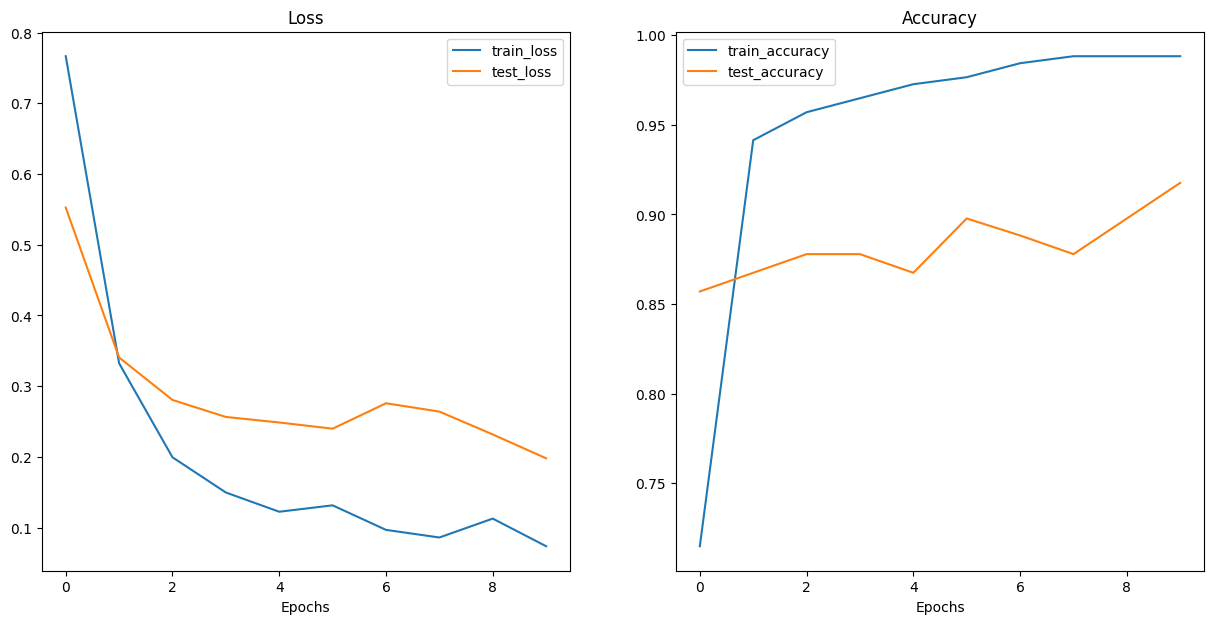

In [72]:
plot_loss_curves(results)

### 10.6 Save our best performing ViT model

In [73]:
# Save the model
from going_modular.going_modular import utils

utils.save_model(model = vit2,
                 target_dir = "models",
                 model_name = "08_pretrained_vit_feature_extractor_pizza_steak_sushi.pth")

[INFO] Saving model to: models/08_pretrained_vit_feature_extractor_pizza_steak_sushi.pth


In [74]:
from pathlib import Path

# Get the model size in bytes then convert to megabytes
vit2_model_size = Path("models/08_pretrained_vit_feature_extractor_pizza_steak_sushi.pth").stat().st_size // (1024*1024)
print(f"Model Size: {vit2_model_size}")

Model Size: 327


## 11. Predicting on a custom image

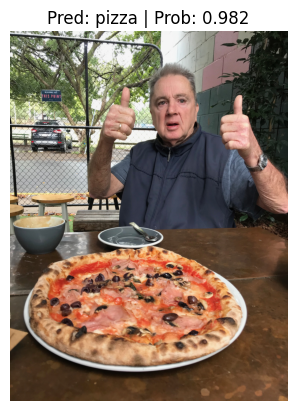

In [75]:
import requests

# Import function to make predictions on images and plot them
from going_modular.going_modular.predictions import pred_and_plot_image

# Setup custom image path
custom_image_path = image_path / "04-pizza-dad.jpeg"

# Download the image if it doesn't already exist
if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        # When downloading from GitHub, need to use the "raw" file link
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
        print(f"Downloading {custom_image_path}...")
        f.write(request.content)
else:
    print(f"{custom_image_path} already exists, skipping download.")

# Predict on custom image
pred_and_plot_image(model=vit2,
                    image_path=custom_image_path,
                    class_names=class_names)